In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [24]:
# bitmasks for 8-connected neighborhood directions
connected_NW = np.uint8(0b00000001)
connected_N  = np.uint8(0b00000010)
connected_NE = np.uint8(0b00000100)
connected_W  = np.uint8(0b00001000)
connected_E  = np.uint8(0b00010000)
connected_SW = np.uint8(0b00100000)
connected_S  = np.uint8(0b01000000)
connected_SE = np.uint8(0b10000000)

In [3]:
with rasterio.open("Dutch Bill Creek-pass3-graph.tif") as file:
    graph = file.read(1)

In [27]:
plot_slice = (slice(15000 // 2, 19000 // 2), slice(14000 // 2, 18000 // 2))

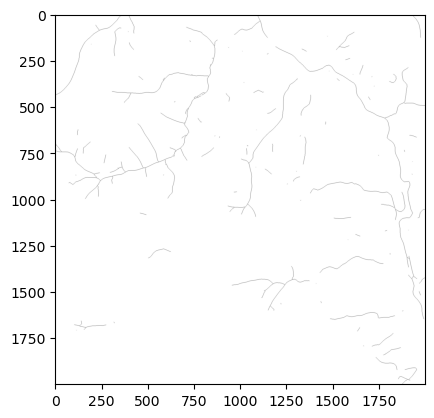

In [28]:
fig, ax = plt.subplots()

ax.imshow(graph[plot_slice] != 0, cmap="gray_r", vmin=0, vmax=1)

None

In [25]:
old_num_connections = 0
for count, binary in sorted([(count, f"{value:08b}") for value, count in zip(*np.unique_counts(graph))], reverse=True):
    num_connections = binary.count("1")
    if num_connections != old_num_connections:
        print()
        old_num_connections = num_connections
    print(f"{binary} with {num_connections} connections in {count} pixels")

00000000 with 0 connections in 112983038 pixels

01000010 with 2 connections in 38510 pixels
00011000 with 2 connections in 38339 pixels
10000001 with 2 connections in 25612 pixels
00100100 with 2 connections in 24331 pixels
01000100 with 2 connections in 16296 pixels
00100010 with 2 connections in 16271 pixels
10001000 with 2 connections in 16183 pixels
00010001 with 2 connections in 16166 pixels
00110000 with 2 connections in 15077 pixels
00001100 with 2 connections in 15069 pixels
01000001 with 2 connections in 14978 pixels
10000010 with 2 connections in 14971 pixels
00000101 with 2 connections in 710 pixels
10100000 with 2 connections in 702 pixels
00100001 with 2 connections in 663 pixels
10000100 with 2 connections in 638 pixels

00000001 with 1 connections in 574 pixels
10000000 with 1 connections in 573 pixels
00100000 with 1 connections in 568 pixels
00000100 with 1 connections in 563 pixels
00010000 with 1 connections in 517 pixels
00001000 with 1 connections in 499 pixels
00

In [42]:
num_connections = np.unpackbits(graph).reshape(graph.shape + (8,)).sum(axis=-1)[plot_slice]

In [43]:
conn1i, conn1j = np.nonzero(num_connections == 1)

In [49]:
conn3i, conn3j = np.nonzero(num_connections >= 3)

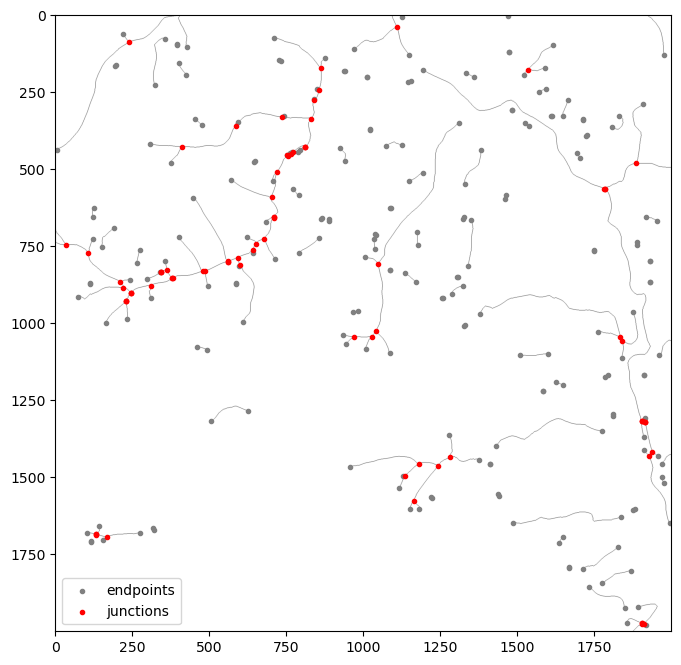

In [55]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(num_connections == 2, cmap="gray_r", vmin=0, vmax=1)
ax.scatter(conn1j, conn1i, marker=".", color="gray", label="endpoints")
ax.scatter(conn3j, conn3i, marker=".", color="red", label="junctions")

ax.legend(loc="lower left")

None